<a href="https://colab.research.google.com/github/Timang419/deep-learning-for-mortgage-/blob/main/script5_full_vram_no_prefetch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install hdf5plugin optuna --quiet


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.9/44.9 MB 61.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 42.2 MB/s eta 0:00:00


In [ ]:
import os
n_cpus = os.cpu_count()
print(f"Available CPUs: {n_cpus}")

# Must be set BEFORE any h5py import — speeds up the one-time full-array read
os.environ["HDF5_PLUGIN_MAX_THREADS"] = str(n_cpus)


Available CPUs: 12


In [ ]:
import os
import gc
import json
import time
import warnings

import numpy as np
import hdf5plugin  # MUST import before h5py to register LZ4
import h5py
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import matplotlib.pyplot as plt
import optuna
from optuna.samplers import TPESampler

warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)


In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)


Mounted at /content/drive


In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
if device.type == 'cuda':
    print(f'VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')
    _cap = torch.cuda.get_device_capability()
    AMP_DTYPE = torch.bfloat16 if _cap[0] >= 8 else torch.float16
else:
    AMP_DTYPE = torch.float16


Device: cuda
VRAM: 85.1 GB


# SECTION 1 — Paths & Constants

No `CHUNK_ROWS` / `HPO_TRAIN_ROWS` / `HPO_VAL_ROWS` — the full panel is small enough (~51 GB train+val, float32) to live on GPU for the whole run, so HPO now uses **all** train rows and **all** val rows, not a subset.

In [ ]:
# ── Paths ──────────────────────────────────────────────────────────────────────
PANEL_DIR  = '/content/drive/MyDrive/dissertation/pool_monthly'
OUTPUT_DIR = '/content/drive/MyDrive/dissertation/pool_monthly/model_full'
os.makedirs(OUTPUT_DIR, exist_ok=True)
CKPT_FILE  = os.path.join(OUTPUT_DIR, 'script5_checkpoint.json')

TRAIN_PATH = os.path.join(PANEL_DIR, 'panel_train.h5')
VAL_PATH   = os.path.join(PANEL_DIR, 'panel_val.h5')
TEST_PATHS = [os.path.join(PANEL_DIR, 'panel_test.h5')]

# ── Training constants ─────────────────────────────────────────────────────────
BATCH_SIZE     = 16384
RANDOM_SEED    = 42

# Logistic: fixed lr, grid search over weight_decay, NO scheduler
LOG_LR         = 1e-3
LOG_WD_GRID    = [1e-5, 1e-4, 1e-3, 1e-2]
LOG_EPOCHS     = 15

# MLP: Optuna HPO, cosine annealing
MLP_HPO_TRIALS = 20
MLP_EPOCHS     = 15

# ── 7-state targets (must match Script 4 TARGET_COLS order) ───────────────────
STATE_NAMES  = ['current', 'd30', 'd60', 'd90p', 'foreclosure', 'reo', 'paidoff']
TARGET_NAMES = [f'target_{s}' for s in STATE_NAMES]
N_TARGETS    = len(TARGET_NAMES)   # 7

torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

# Detect N_FEATURES from the train shard
with h5py.File(TRAIN_PATH, 'r') as _f:
    N_FEATURES = _f['X'].shape[1]
    FEAT_COLS  = list(_f['X'].attrs.get('col_names', []))

print(f'N_FEATURES     : {N_FEATURES}')
print(f'BATCH_SIZE     : {BATCH_SIZE}')
print(f'LOG_EPOCHS     : {LOG_EPOCHS}')
print(f'MLP_EPOCHS     : {MLP_EPOCHS}')
print(f'TARGET_NAMES   : {TARGET_NAMES}')


N_FEATURES     : 178
BATCH_SIZE     : 16384
LOG_EPOCHS     : 15
MLP_EPOCHS     : 15
TARGET_NAMES   : ['target_current', 'target_d30', 'target_d60', 'target_d90p', 'target_foreclosure', 'target_reo', 'target_paidoff']


# SECTION 2 — Checkpoint, Model, Metrics

In [ ]:
# ── Checkpoint helpers ─────────────────────────────────────────────────────────
def ckpt_load():
    if os.path.exists(CKPT_FILE):
        with open(CKPT_FILE) as f:
            c = json.load(f)
        print(f'[CKPT] Resuming: {list(c.keys())}')
        return c
    return {}

def ckpt_save(state):
    with open(CKPT_FILE, 'w') as f:
        json.dump(state, f, indent=2)
    print('[CKPT] Saved.', flush=True)


In [ ]:
class PoolNet(nn.Module):
    """
    Monthly pool-level model — mirrors MortgageNet architecture from Script 3.

    depth=0  -> zero hidden layers (multinomial logistic regression, Model 2)
    depth>0  -> pool-level MLP (Model 3)

    num_classes=7 — one logit per transition target state.
    nn.CrossEntropyLoss with a 2D float target computes soft cross-entropy
    (equivalent to KL divergence up to the constant target entropy).
    """
    def __init__(self, input_dim, num_classes=7,
                 depth=2, hidden_dim=128,
                 dropout_rate=0.3, norm_type='batch'):
        super().__init__()
        layers, d = [], input_dim
        for _ in range(depth):
            layers.append(nn.Linear(d, hidden_dim))
            if norm_type == 'batch':
                layers.append(nn.BatchNorm1d(hidden_dim))
            elif norm_type == 'layer':
                layers.append(nn.LayerNorm(hidden_dim))
            # norm_type == 'none': no normalisation layer
            layers.append(nn.ReLU())
            if dropout_rate > 0.0:
                layers.append(nn.Dropout(p=dropout_rate))
            d = hidden_dim
        self.hidden_layers = nn.Sequential(*layers)
        self.output_layer  = nn.Linear(d, num_classes)

    def forward(self, x):
        return self.output_layer(self.hidden_layers(x))


def make_optimizer(model, lr, weight_decay):
    """AdamW: weight decay on 2-D params only (bias / norm excluded)."""
    decay    = [p for p in model.parameters() if p.ndim >= 2]
    no_decay = [p for p in model.parameters() if p.ndim <  2]
    return optim.AdamW([
        {'params': decay,    'weight_decay': weight_decay},
        {'params': no_decay, 'weight_decay': 0.0},
    ], lr=lr)


print('PoolNet + make_optimizer defined.')
for d in [0, 3, 4,5]:
    n = sum(p.numel() for p in PoolNet(N_FEATURES, depth=d).parameters())
    print(f'  PoolNet depth={d}: {n:,} parameters')


PoolNet + make_optimizer defined.
  PoolNet depth=0: 1,253 parameters
  PoolNet depth=3: 57,607 parameters
  PoolNet depth=4: 74,375 parameters
  PoolNet depth=5: 91,143 parameters


In [ ]:
def compute_metrics(preds: np.ndarray, targets: np.ndarray) -> dict:
    """MAE and RMSE per state + overall average (7 states)."""
    metrics = {}
    for i, name in enumerate(STATE_NAMES):
        metrics[f'MAE_{name}']  = float(np.abs(preds[:, i] - targets[:, i]).mean())
        metrics[f'RMSE_{name}'] = float(
            np.sqrt(((preds[:, i] - targets[:, i]) ** 2).mean()))
    metrics['MAE_overall']  = float(np.mean(
        [metrics[f'MAE_{n}']  for n in STATE_NAMES]))
    metrics['RMSE_overall'] = float(np.mean(
        [metrics[f'RMSE_{n}'] for n in STATE_NAMES]))
    return metrics


def soft_ce_numpy(preds: np.ndarray, targets: np.ndarray) -> float:
    """Soft cross-entropy: -mean_i sum_k p_k log q_k."""
    log_q = np.log(np.clip(preds, 1e-10, 1.0))
    return float(-(targets * log_q).sum(axis=1).mean())


print('Metrics defined.')


Metrics defined.


# SECTION 3 — Load train+val into ONE combined VRAM buffer

No prefetcher, no chunk streaming. Instead of `torch.cat([X_train_gpu, X_val_gpu])`
(which would momentarily need train+val resident **twice** — ~100 GB, doesn't fit
on an 80 GB card), allocate a single buffer sized for `n_train + n_val` up front and
fill it in two slices:

- `X_combined[:n_train]` and `X_combined[n_train:]` are **views**, not copies — they
  give you train-only / val-only access for grid search and Optuna at zero extra memory.
- `X_combined` itself, used directly, *is* the train+val-combined data for final training.

Peak VRAM: ~51 GB for the whole run (HPO and final training both), comfortably under 80 GB.

In [ ]:
def load_combined_train_val(train_path, val_path):
    """
    Loads train and val into one contiguous (n_train+n_val, N_FEATURES) GPU buffer.
    Returns the combined X/y tensors plus n_train (the split point) so callers can
    take views: X_combined[:n_train] (train) and X_combined[n_train:] (val).
    """
    with h5py.File(train_path, 'r') as f:
        n_train = f['X'].shape[0]
    with h5py.File(val_path, 'r') as f:
        n_val = f['X'].shape[0]
    n_total = n_train + n_val

    print(f'  Allocating combined buffer: {n_total:,} rows x {N_FEATURES} features '
          f'(~{n_total * N_FEATURES * 4 / 1e9:.1f} GB)...')
    X_combined = torch.empty((n_total, N_FEATURES), dtype=torch.float32, device=device)
    y_combined = torch.empty((n_total, N_TARGETS),  dtype=torch.float32, device=device)

    CHUNK_ROWS = 5_000_000   # ~3.6 GB per chunk in host RAM, instead of 45 GB at once

    t0 = time.time()
    with h5py.File(train_path, 'r') as f:
        for i in range(0, n_train, CHUNK_ROWS):
            end = min(i + CHUNK_ROWS, n_train)
            X_combined[i:end] = torch.from_numpy(f['X'][i:end])
            y_combined[i:end] = torch.from_numpy(f['y'][i:end])
    print(f'  Train loaded ({n_train:,} rows) in {time.time() - t0:.0f}s')

    t0 = time.time()
    with h5py.File(val_path, 'r') as f:
        for i in range(0, n_val, CHUNK_ROWS):
            end = min(i + CHUNK_ROWS, n_val)
            X_combined[n_train + i : n_train + end] = torch.from_numpy(f['X'][i:end])
            y_combined[n_train + i : n_train + end] = torch.from_numpy(f['y'][i:end])
    print(f'  Val loaded ({n_val:,} rows) in {time.time() - t0:.0f}s')

    gc.collect()
    if device.type == 'cuda':
        used  = torch.cuda.memory_allocated() / 1e9
        total = torch.cuda.get_device_properties(0).total_memory / 1e9
        print(f'  VRAM used: {used:.1f} / {total:.1f} GB')

    return X_combined, y_combined, n_train, n_val


def load_test_full(paths):
    """Test set is small (~2.5 GB) — load fully, no special handling needed."""
    X_parts, y_parts, ids_parts, mo_parts = [], [], [], []
    for p in paths:
        with h5py.File(p, 'r') as f:
            X_parts.append(f['X'][:])
            y_parts.append(f['y'][:])
            ids_parts.append(f['pool_ids'][:])
            mo_parts.append(f['Reporting_Period_Int'][:])
    X = np.concatenate(X_parts, axis=0)
    y = np.concatenate(y_parts, axis=0)
    pool_ids = np.concatenate(ids_parts, axis=0)
    months   = np.concatenate(mo_parts, axis=0)
    return X, y, pool_ids, months


print('load_combined_train_val / load_test_full defined.')


load_combined_train_val / load_test_full defined.


# SECTION 4 — Training Utilities (pure GPU tensor slicing, no DataLoader)

In [ ]:
criterion = nn.CrossEntropyLoss()
# nn.CrossEntropyLoss with a 2D float target computes soft cross-entropy:
#   -sum_k [ p_k * log_softmax(logits)_k ]   (raw logits required)


def train_epoch_gpu(model, X_gpu, y_gpu, optimizer):
    """One epoch over an in-VRAM split."""
    model.train()
    n = len(X_gpu)
    total_loss = 0.0
    idx = torch.randperm(n, device=device)
    n_batches = 0
    for start in range(0, n - BATCH_SIZE + 1, BATCH_SIZE):
        b = idx[start:start + BATCH_SIZE]
        X_b, y_b = X_gpu[b], y_gpu[b]
        optimizer.zero_grad()
        with torch.autocast(device_type='cuda', dtype=AMP_DTYPE,
                            enabled=device.type == 'cuda'):
            loss = criterion(model(X_b), y_b)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item() * len(b)
        n_batches  += len(b)
    return total_loss / n_batches


@torch.no_grad()
def evaluate_gpu(model, X_gpu, y_gpu):
    """Evaluate on an in-VRAM split. Returns (avg_loss, probs, targets) as numpy."""
    model.eval()
    n = len(X_gpu)
    total_loss = 0.0
    probs_lst, targets_lst = [], []
    for start in range(0, n, BATCH_SIZE):
        X_b = X_gpu[start:start + BATCH_SIZE]
        y_b = y_gpu[start:start + BATCH_SIZE]
        with torch.autocast(device_type='cuda', dtype=AMP_DTYPE,
                            enabled=device.type == 'cuda'):
            logits = model(X_b)
            loss   = criterion(logits, y_b)
        total_loss += loss.item() * len(X_b)
        probs_lst.append(F.softmax(logits, dim=1).float().cpu().numpy())
        targets_lst.append(y_b.cpu().numpy())
    probs   = np.concatenate(probs_lst)
    targets = np.concatenate(targets_lst)
    return total_loss / n, probs, targets


def train_fixed_epochs_gpu(model, X_gpu, y_gpu, lr, weight_decay, n_epochs,
                            model_name='', verbose=False, use_scheduler=True):
    """
    Fixed-epoch training on in-VRAM tensors. No early stopping (patience=999
    equivalent) — matches the Script 3 final-training protocol.

    use_scheduler=False -> logistic (constant LR)
    use_scheduler=True  -> MLP (cosine annealing)
    """
    optimizer = make_optimizer(model, lr, weight_decay)
    scheduler = (
        optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=n_epochs, eta_min=1e-5)
        if use_scheduler else None
    )
    history = []
    for epoch in range(n_epochs):
        loss = train_epoch_gpu(model, X_gpu, y_gpu, optimizer)
        if scheduler is not None:
            scheduler.step()
        history.append(loss)
        if verbose:
            lr_now = optimizer.param_groups[0]['lr']
            print(f'  [{model_name}] epoch {epoch + 1:2d}/{n_epochs}  '
                  f'loss={loss:.4f}  lr={lr_now:.2e}')
    return model, history


def train_final_both_gpu(log_model, mlp_model, X_gpu, y_gpu,
                          log_lr, log_wd, mlp_lr, mlp_wd, epochs):
    """
    Train Logistic Regression and Pool MLP SIMULTANEOUSLY on the train+val
    combined data — both models see the same per-epoch shuffle order and the
    same batch each step. Matches the original train_sharded_both protocol,
    just without chunking (everything is already resident in VRAM).

    Logistic: constant LR, NO scheduler.
    MLP:      cosine annealing over `epochs`.

    Requires log/mlp epoch counts to be equal (they share one shuffle loop).
    """
    n = len(X_gpu)
    log_opt = make_optimizer(log_model, log_lr, log_wd)
    mlp_opt = make_optimizer(mlp_model, mlp_lr, mlp_wd)
    mlp_scheduler = optim.lr_scheduler.CosineAnnealingLR(mlp_opt, T_max=epochs, eta_min=1e-5)

    log_history, mlp_history = [], []

    for epoch in range(1, epochs + 1):
        log_model.train()
        mlp_model.train()
        idx = torch.randperm(n, device=device)
        log_total = mlp_total = n_seen = 0.0

        for start in range(0, n - BATCH_SIZE + 1, BATCH_SIZE):
            b = idx[start:start + BATCH_SIZE]
            X_b, y_b = X_gpu[b], y_gpu[b]   # same batch feeds both models

            # -- Logistic step --------------------------------------------
            log_opt.zero_grad()
            with torch.autocast(device_type='cuda', dtype=AMP_DTYPE,
                                enabled=device.type == 'cuda'):
                loss_log = criterion(log_model(X_b), y_b)
            loss_log.backward()
            torch.nn.utils.clip_grad_norm_(log_model.parameters(), max_norm=1.0)
            log_opt.step()

            # -- MLP step (same X_b, y_b) ----------------------------------
            mlp_opt.zero_grad()
            with torch.autocast(device_type='cuda', dtype=AMP_DTYPE,
                                enabled=device.type == 'cuda'):
                loss_mlp = criterion(mlp_model(X_b), y_b)
            loss_mlp.backward()
            torch.nn.utils.clip_grad_norm_(mlp_model.parameters(), max_norm=1.0)
            mlp_opt.step()

            log_total += loss_log.item() * len(b)
            mlp_total += loss_mlp.item() * len(b)
            n_seen    += len(b)

        mlp_scheduler.step()
        log_history.append(log_total / n_seen)
        mlp_history.append(mlp_total / n_seen)
        print(f'  Epoch {epoch:2d}/{epochs} | LogReg: {log_history[-1]:.4f} | '
              f'MLP: {mlp_history[-1]:.4f}')

    return log_model, mlp_model, log_history, mlp_history


print('Training utilities defined (including simultaneous final-training loop).')


Training utilities defined (including simultaneous final-training loop).


# SECTION 5 — Main Pipeline
## Step 1: Load combined train+val into VRAM

In [ ]:
import shutil
import time

# 1. Define local directory
LOCAL_DIR = '/content/local_panel'
os.makedirs(LOCAL_DIR, exist_ok=True)

print("Starting transfer from Google Drive to Local Colab SSD...")

# 2. Copy the files sequentially (this maximizes Drive throughput)
for filename in ['panel_train.h5', 'panel_val.h5', 'panel_test.h5']:
    src = os.path.join(PANEL_DIR, filename)
    dst = os.path.join(LOCAL_DIR, filename)

    if not os.path.exists(dst):
        print(f"  Copying {filename}...")
        t0 = time.time()
        shutil.copy2(src, dst)
        print(f"  -> Done in {time.time() - t0:.0f}s")
    else:
        print(f"  {filename} already exists locally.")

# 3. Remap your paths to point to the blazing-fast local SSD
TRAIN_PATH = os.path.join(LOCAL_DIR, 'panel_train.h5')
VAL_PATH   = os.path.join(LOCAL_DIR, 'panel_val.h5')
TEST_PATHS = [os.path.join(LOCAL_DIR, 'panel_test.h5')]

print("\nPaths successfully remapped. Ready for Step 1.")

Starting transfer from Google Drive to Local Colab SSD...
  Copying panel_train.h5...
  -> Done in 313s
  Copying panel_val.h5...
  -> Done in 40s
  Copying panel_test.h5...
  -> Done in 25s

Paths successfully remapped. Ready for Step 1.


In [ ]:
ckpt = ckpt_load()

# Only need train/val resident if final training hasn't happened yet.
# (Once final_train_done is True we only need the test set + saved weights.)
need_traincombined = not ckpt.get('final_train_done')

if need_traincombined:
    print('Loading combined train+val buffer...')
    X_combined, y_combined, N_TRAIN, N_VAL = load_combined_train_val(TRAIN_PATH, VAL_PATH)
    X_train_gpu, y_train_gpu = X_combined[:N_TRAIN], y_combined[:N_TRAIN]   # views
    X_val_gpu,   y_val_gpu   = X_combined[N_TRAIN:], y_combined[N_TRAIN:]   # views
    print(f'  Train view: {len(X_train_gpu):,} rows | Val view: {len(X_val_gpu):,} rows')
else:
    print('[CKPT] Final training already done — skipping train/val load.')


[CKPT] Resuming: ['baseline_pred', 'log_hpo_done', 'best_log_wd', 'best_log_val_ce', 'log_grid_results']
Loading combined train+val buffer...
  Allocating combined buffer: 69,044,582 rows x 178 features (~49.2 GB)...
  Train loaded (63,201,640 rows) in 124s
  Val loaded (5,842,942 rows) in 12s
  VRAM used: 51.1 / 85.1 GB
  Train view: 63,201,640 rows | Val view: 5,842,942 rows


## Step 2: Model 1 — Empirical Baseline

In [ ]:
print('=' * 65)
print('MODEL 1 — Empirical Baseline (train+val combined)')
print('=' * 65)

if not ckpt.get('baseline_pred'):
    baseline_pred = (y_combined.double().mean(dim=0)).cpu().numpy()
    baseline_pred = baseline_pred / baseline_pred.sum()
    ckpt['baseline_pred'] = baseline_pred.tolist()
    ckpt_save(ckpt)
else:
    baseline_pred = np.array(ckpt['baseline_pred'])
    print('[CKPT] Baseline loaded from checkpoint.')

print('\nBaseline predictions (train+val mean):')
for name, p in zip(STATE_NAMES, baseline_pred):
    print(f'  {name:15s}: {p:.4f}')
print(f'  Sum: {baseline_pred.sum():.6f}')
assert abs(baseline_pred.sum() - 1.0) < 1e-4


MODEL 1 — Empirical Baseline (train+val combined)
[CKPT] Baseline loaded from checkpoint.

Baseline predictions (train+val mean):
  current        : 0.3356
  d30            : 0.0035
  d60            : 0.0009
  d90p           : 0.0010
  foreclosure    : 0.0019
  reo            : 0.0083
  paidoff        : 0.6489
  Sum: 1.000000


## Step 3: Model 2 — Logistic Regression (grid search, full train/val)

In [ ]:
print('\n' + '=' * 65)
print('MODEL 2 — Logistic Regression (depth=0)')
print('=' * 65)

if not ckpt.get('log_hpo_done'):
    print(f'Grid search: fixed lr={LOG_LR:.0e}  x  {len(LOG_WD_GRID)} weight decays  '
          f'|  NO scheduler  |  full train ({len(X_train_gpu):,} rows) / full val')
    best_log_wd     = None
    best_log_val_ce = float('inf')
    grid_results    = []

    for wd in LOG_WD_GRID:
        model = PoolNet(N_FEATURES, depth=0).to(device)
        model, _ = train_fixed_epochs_gpu(
            model, X_train_gpu, y_train_gpu, LOG_LR, wd,
            n_epochs=LOG_EPOCHS, model_name=f'Log-grid wd={wd:.0e}',
            verbose=False, use_scheduler=False)
        val_ce, _, _ = evaluate_gpu(model, X_val_gpu, y_val_gpu)

        marker = '  <- best' if val_ce < best_log_val_ce else ''
        print(f'  wd={wd:.0e}  val_ce={val_ce:.4f}{marker}')
        grid_results.append({'wd': wd, 'val_ce': val_ce})
        if val_ce < best_log_val_ce:
            best_log_val_ce = val_ce
            best_log_wd     = wd
        del model; gc.collect(); torch.cuda.empty_cache()

    print(f'\nBest: lr={LOG_LR:.0e}  wd={best_log_wd:.0e}  val_ce={best_log_val_ce:.4f}')
    ckpt['log_hpo_done']     = True
    ckpt['best_log_wd']      = best_log_wd
    ckpt['best_log_val_ce']  = best_log_val_ce
    ckpt['log_grid_results'] = grid_results
    ckpt_save(ckpt)
else:
    best_log_wd     = ckpt['best_log_wd']
    best_log_val_ce = ckpt['best_log_val_ce']
    print(f'[CKPT] Logistic HPO done -> best_wd={best_log_wd:.0e}  '
          f'val_ce={best_log_val_ce:.4f}')



MODEL 2 — Logistic Regression (depth=0)
[CKPT] Logistic HPO done -> best_wd=1e-02  val_ce=0.5864


## Step 4: Model 3 — Pool MLP (Optuna HPO, full train/val)

In [ ]:
print('\n' + '=' * 65)
print(f'MODEL 3 — Pool MLP (Optuna, {MLP_HPO_TRIALS} trials, cosine annealing, '
      f'full train/val)')
print('=' * 65)

if not ckpt.get('mlp_hpo_done'):
    def mlp_objective(trial):
        cfg = dict(
            depth        = trial.suggest_categorical('depth',      [3, 4, 5]),
            hidden_dim   = trial.suggest_categorical('hidden_dim', [128, 256, 512]),
            dropout      = trial.suggest_categorical('dropout',    [0.0, 0.1, 0.2, 0.3]),
            norm_type    = trial.suggest_categorical('norm_type',  ['batch', 'layer', 'none']),
            lr           = trial.suggest_float('lr',           1e-4, 1e-2, log=True),
            weight_decay = trial.suggest_float('weight_decay', 1e-6, 1e-3, log=True),
        )
        model = PoolNet(
            N_FEATURES,
            depth        = cfg['depth'],
            hidden_dim   = cfg['hidden_dim'],
            dropout_rate = cfg['dropout'],
            norm_type    = cfg['norm_type'],
        ).to(device)
        model, _ = train_fixed_epochs_gpu(
            model, X_train_gpu, y_train_gpu,
            lr=cfg['lr'], weight_decay=cfg['weight_decay'],
            n_epochs=MLP_EPOCHS, model_name=f'Pool-t{trial.number}',
            verbose=False, use_scheduler=True)
        val_ce, _, _ = evaluate_gpu(model, X_val_gpu, y_val_gpu)
        del model; gc.collect(); torch.cuda.empty_cache()
        return val_ce

    def print_trial_callback(study, trial):
        print(f'  Trial {trial.number + 1}/{MLP_HPO_TRIALS} done | val_ce={trial.value:.4f} | '
              f'best so far={study.best_value:.4f}')

    print(f'Running Optuna ({MLP_HPO_TRIALS} trials)...')
    mlp_study = optuna.create_study(
        direction='minimize', sampler=TPESampler(seed=RANDOM_SEED))
    mlp_study.optimize(mlp_objective, n_trials=MLP_HPO_TRIALS, callbacks=[print_trial_callback])

    best_mlp_params = mlp_study.best_params
    df = mlp_study.trials_dataframe()
    keep_cols = ['number', 'value'] + [c for c in df.columns if c.startswith('params_')]
    mlp_trial_results = df[keep_cols].to_dict('records')

    print(f'Best HPO params : {best_mlp_params}')
    print(f'Best val CE     : {mlp_study.best_value:.4f}')
    ckpt['mlp_hpo_done']      = True
    ckpt['best_mlp_params']   = best_mlp_params
    ckpt['mlp_hpo_val_ce']    = mlp_study.best_value
    ckpt['mlp_trial_results'] = mlp_trial_results
    ckpt_save(ckpt)
else:
    best_mlp_params = ckpt['best_mlp_params']
    print(f'[CKPT] MLP HPO done -> {best_mlp_params}')


MODEL 3 — Pool MLP (Optuna, 20 trials, cosine annealing, full train/val)
Running Optuna (20 trials)...
  Trial 1/20 done | val_ce=0.6004 | best so far=0.6004
  Trial 2/20 done | val_ce=0.5778 | best so far=0.5778
  Trial 3/20 done | val_ce=0.5744 | best so far=0.5744
  Trial 4/20 done | val_ce=0.6028 | best so far=0.5744
  Trial 5/20 done | val_ce=0.5738 | best so far=0.5738
  Trial 6/20 done | val_ce=0.5738 | best so far=0.5738
  Trial 7/20 done | val_ce=0.5771 | best so far=0.5738
  Trial 8/20 done | val_ce=0.6026 | best so far=0.5738
  Trial 9/20 done | val_ce=0.5896 | best so far=0.5738
  Trial 10/20 done | val_ce=0.5880 | best so far=0.5738
  Trial 11/20 done | val_ce=0.5754 | best so far=0.5738
  Trial 12/20 done | val_ce=1.2006 | best so far=0.5738
  Trial 13/20 done | val_ce=0.5732 | best so far=0.5732
  Trial 14/20 done | val_ce=0.5757 | best so far=0.5732
  Trial 15/20 done | val_ce=0.5773 | best so far=0.5732
  Trial 16/20 done | val_ce=0.5897 | best so far=0.5732
  Trial 1

## Step 5: Final Training — train+val combined, fixed epochs, no early stopping


FINAL TRAINING — Logistic + MLP on train+val combined
  Logistic: constant LR (no scheduler)
  MLP:      cosine annealing
  Training rows (combined): 69,044,582
  Epoch  1/15 | LogReg: 0.5034 | MLP: 0.4763
  Epoch  2/15 | LogReg: 0.4847 | MLP: 0.4732
  Epoch  3/15 | LogReg: 0.4837 | MLP: 0.4729
  Epoch  4/15 | LogReg: 0.4830 | MLP: 0.4727
  Epoch  5/15 | LogReg: 0.4826 | MLP: 0.4727
  Epoch  6/15 | LogReg: 0.4823 | MLP: 0.4726
  Epoch  7/15 | LogReg: 0.4821 | MLP: 0.4726
  Epoch  8/15 | LogReg: 0.4820 | MLP: 0.4725
  Epoch  9/15 | LogReg: 0.4819 | MLP: 0.4725
  Epoch 10/15 | LogReg: 0.4818 | MLP: 0.4725
  Epoch 11/15 | LogReg: 0.4818 | MLP: 0.4724
  Epoch 12/15 | LogReg: 0.4818 | MLP: 0.4724
  Epoch 13/15 | LogReg: 0.4817 | MLP: 0.4724
  Epoch 14/15 | LogReg: 0.4817 | MLP: 0.4724
  Epoch 15/15 | LogReg: 0.4817 | MLP: 0.4724
[CKPT] Saved.

Freeing combined train+val VRAM...
  VRAM now: 0.0 GB used


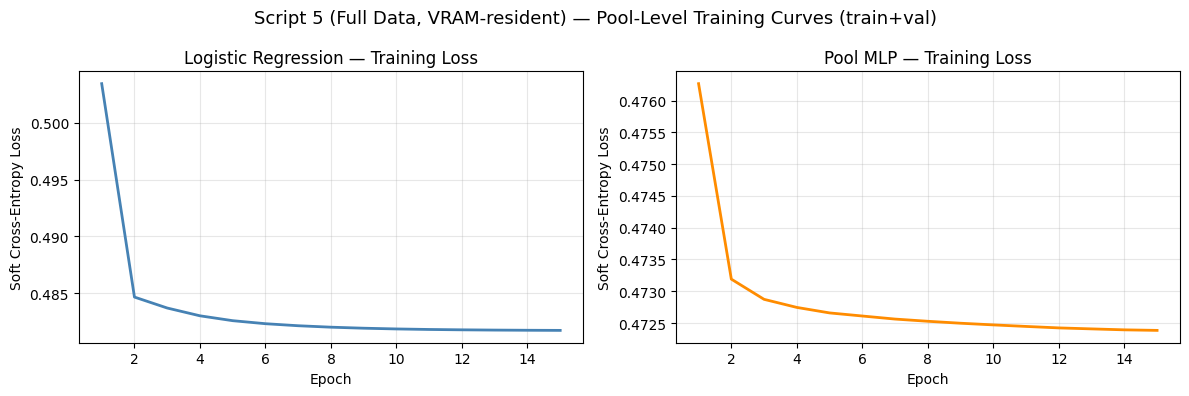

Saved training curves: /content/drive/MyDrive/dissertation/pool_monthly/model_full/panel_training_curves.png


In [ ]:
print('\n' + '=' * 65)
print('FINAL TRAINING — Logistic + MLP on train+val combined')
print('  Logistic: constant LR (no scheduler)')
print('  MLP:      cosine annealing')
print('=' * 65)

log_save_path = os.path.join(OUTPUT_DIR, 'panel_logistic_best.pt')
mlp_save_path = os.path.join(OUTPUT_DIR, 'panel_mlp_best.pt')

if not ckpt.get('final_train_done'):
    print(f'  Training rows (combined): {len(X_combined):,}')
    assert LOG_EPOCHS == MLP_EPOCHS, (
        'train_final_both_gpu shares one shuffle loop for both models — '
        'LOG_EPOCHS and MLP_EPOCHS must match.')

    log_model = PoolNet(N_FEATURES, depth=0).to(device)
    mlp_model = PoolNet(
        N_FEATURES,
        depth        = best_mlp_params['depth'],
        hidden_dim   = best_mlp_params['hidden_dim'],
        dropout_rate = best_mlp_params['dropout'],
        norm_type    = best_mlp_params['norm_type'],
    ).to(device)

    log_model, mlp_model, log_hist, mlp_hist = train_final_both_gpu(
        log_model, mlp_model, X_combined, y_combined,
        log_lr=LOG_LR, log_wd=best_log_wd,
        mlp_lr=best_mlp_params['lr'], mlp_wd=best_mlp_params['weight_decay'],
        epochs=LOG_EPOCHS)

    torch.save({
        'model_state_dict': log_model.state_dict(),
        'model_class':      'PoolNet',
        'depth':            0,
        'num_classes':      N_TARGETS,
        'n_features':       N_FEATURES,
        'best_lr':          LOG_LR,
        'best_wd':          best_log_wd,
        'best_val_ce':      best_log_val_ce,
        'state_names':      STATE_NAMES,
        'target_names':     TARGET_NAMES,
        'feature_cols':     FEAT_COLS,
    }, log_save_path)

    torch.save({
        'model_state_dict': mlp_model.state_dict(),
        'model_class':      'PoolNet',
        'num_classes':      N_TARGETS,
        'n_features':       N_FEATURES,
        'depth':            best_mlp_params['depth'],
        'hidden_dim':       best_mlp_params['hidden_dim'],
        'dropout_rate':     best_mlp_params['dropout'],
        'norm_type':        best_mlp_params['norm_type'],
        'hpo_params':       best_mlp_params,
        'state_names':      STATE_NAMES,
        'target_names':     TARGET_NAMES,
        'feature_cols':     FEAT_COLS,
    }, mlp_save_path)

    ckpt['final_train_done'] = True
    ckpt['log_hist']         = log_hist
    ckpt['mlp_hist']         = mlp_hist
    ckpt_save(ckpt)

    # Free the combined buffer — no longer needed once final weights are saved
    print('\nFreeing combined train+val VRAM...')
    del X_combined, y_combined, X_train_gpu, y_train_gpu, X_val_gpu, y_val_gpu
    gc.collect(); torch.cuda.empty_cache()
    if device.type == 'cuda':
        print(f'  VRAM now: {torch.cuda.memory_allocated() / 1e9:.1f} GB used')

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(range(1, LOG_EPOCHS + 1), log_hist, color='steelblue', linewidth=2)
    axes[0].set_title('Logistic Regression — Training Loss')
    axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Soft Cross-Entropy Loss')
    axes[0].grid(True, alpha=0.3)
    axes[1].plot(range(1, MLP_EPOCHS + 1), mlp_hist, color='darkorange', linewidth=2)
    axes[1].set_title('Pool MLP — Training Loss')
    axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Soft Cross-Entropy Loss')
    axes[1].grid(True, alpha=0.3)
    plt.suptitle('Script 5 (Full Data, VRAM-resident) — Pool-Level Training Curves '
                 '(train+val)', fontsize=13)
    plt.tight_layout()
    curve_path = os.path.join(OUTPUT_DIR, 'panel_training_curves.png')
    plt.savefig(curve_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved training curves: {curve_path}')

else:
    print('[CKPT] Final training done — reloading model weights...')
    log_model = PoolNet(N_FEATURES, depth=0).to(device)
    mlp_model = PoolNet(
        N_FEATURES,
        depth        = best_mlp_params['depth'],
        hidden_dim   = best_mlp_params['hidden_dim'],
        dropout_rate = best_mlp_params['dropout'],
        norm_type    = best_mlp_params['norm_type'],
    ).to(device)
    log_model.load_state_dict(
        torch.load(log_save_path, map_location=device)['model_state_dict'])
    mlp_model.load_state_dict(
        torch.load(mlp_save_path, map_location=device)['model_state_dict'])
    print('  Weights loaded.')


## Step 6: Test Evaluation

In [ ]:
print('\n' + '=' * 65)
print('TEST EVALUATION')
print('=' * 65)

if not ckpt.get('final_eval_done'):
    X_test_np, y_test_np, pool_ids_test, months_test = load_test_full(TEST_PATHS)
    X_test_gpu = torch.from_numpy(X_test_np).to(device)
    y_test_gpu = torch.from_numpy(y_test_np).to(device)
    del X_test_np; gc.collect()
    print(f'  Test rows: {len(X_test_gpu):,}')

    base_preds = np.tile(baseline_pred, (len(y_test_np), 1))
    base_ce    = soft_ce_numpy(base_preds, y_test_np)
    base_met   = compute_metrics(base_preds, y_test_np)

    log_ce, log_preds, targets = evaluate_gpu(log_model, X_test_gpu, y_test_gpu)
    log_met = compute_metrics(log_preds, targets)

    mlp_ce, mlp_preds, _ = evaluate_gpu(mlp_model, X_test_gpu, y_test_gpu)
    mlp_met = compute_metrics(mlp_preds, targets)

    preds_path = os.path.join(OUTPUT_DIR, 'panel_test_predictions.npz')
    np.savez(
        preds_path,
        pool_ids       = pool_ids_test,
        report_months  = months_test,
        y_true         = targets,
        baseline_preds = base_preds,
        logistic_preds = log_preds,
        mlp_preds      = mlp_preds,
        state_names    = np.array(STATE_NAMES),
        target_names   = np.array(TARGET_NAMES),
    )
    print(f'Saved test predictions : {preds_path}')

    results = {
        'baseline': {'test_ce_loss': base_ce, 'test_metrics': base_met},
        'logistic': {
            'test_ce_loss': log_ce, 'test_metrics': log_met,
            'best_lr': LOG_LR, 'best_wd': best_log_wd, 'best_val_ce': best_log_val_ce,
        },
        'mlp': {
            'test_ce_loss': mlp_ce, 'test_metrics': mlp_met,
            'hpo_params': best_mlp_params, 'hpo_val_ce': ckpt.get('mlp_hpo_val_ce'),
        },
    }
    results_path = os.path.join(OUTPUT_DIR, 'panel_results.json')
    with open(results_path, 'w') as f:
        json.dump(results, f, indent=2)
    print(f'Saved results JSON      : {results_path}')

    b_ce, b_met = base_ce, base_met
    l_ce, l_met = log_ce, log_met
    m_ce, m_met = mlp_ce, mlp_met

    ckpt['final_eval_done'] = True
    ckpt['final_results']   = results
    ckpt_save(ckpt)
else:
    results = ckpt['final_results']
    b_ce, b_met = results['baseline']['test_ce_loss'], results['baseline']['test_metrics']
    l_ce, l_met = results['logistic']['test_ce_loss'], results['logistic']['test_metrics']
    m_ce, m_met = results['mlp']['test_ce_loss'],      results['mlp']['test_metrics']
    print('[CKPT] Evaluation already done.')



TEST EVALUATION
  Test rows: 3,418,914
Saved test predictions : /content/drive/MyDrive/dissertation/pool_monthly/model_full/panel_test_predictions.npz
Saved results JSON      : /content/drive/MyDrive/dissertation/pool_monthly/model_full/panel_results.json
[CKPT] Saved.


## Results Summary

In [ ]:
print('\n' + '=' * 70)
print('SCRIPT 5 (MONTHLY, FULL DATA, VRAM-RESIDENT) COMPLETE — Results Summary')
print('=' * 70)
print(f'\n{"Metric":<30} {"Baseline":>10} {"Logistic":>10} {"MLP":>10}')
print('-' * 70)
print(f'{"Test CE loss":<30} {b_ce:>10.4f} {l_ce:>10.4f} {m_ce:>10.4f}')
print(f'{"Test MAE overall":<30} '
      f'{b_met["MAE_overall"]:>10.4f} '
      f'{l_met["MAE_overall"]:>10.4f} '
      f'{m_met["MAE_overall"]:>10.4f}')
print(f'{"Test RMSE overall":<30} '
      f'{b_met["RMSE_overall"]:>10.4f} '
      f'{l_met["RMSE_overall"]:>10.4f} '
      f'{m_met["RMSE_overall"]:>10.4f}')
print('-' * 70)
print('\nPer-state test MAE:')
print(f'{"State":<20} {"Baseline":>10} {"Logistic":>10} {"MLP":>10}')
print('-' * 55)
for name in STATE_NAMES:
    print(f'{name:<20} '
          f'{b_met[f"MAE_{name}"]:>10.4f} '
          f'{l_met[f"MAE_{name}"]:>10.4f} '
          f'{m_met[f"MAE_{name}"]:>10.4f}')
print('=' * 70)
print(f'Models and metrics saved to: {OUTPUT_DIR}')
print('Ready for Script 6 (Monte Carlo comparison)')



SCRIPT 5 (MONTHLY, FULL DATA, VRAM-RESIDENT) COMPLETE — Results Summary

Metric                           Baseline   Logistic        MLP
----------------------------------------------------------------------
Test CE loss                       1.0846     0.3692     0.3451
Test MAE overall                   0.1631     0.0151     0.0050
Test RMSE overall                  0.1651     0.0208     0.0071
----------------------------------------------------------------------

Per-state test MAE:
State                  Baseline   Logistic        MLP
-------------------------------------------------------
current                  0.5622     0.0465     0.0135
d30                      0.0067     0.0061     0.0057
d60                      0.0021     0.0020     0.0018
d90p                     0.0023     0.0019     0.0011
foreclosure              0.0027     0.0019     0.0006
reo                      0.0082     0.0004     0.0008
paidoff                  0.5573     0.0469     0.0115
Models and metrics 

In [ ]:
df = mlp_study.trials_dataframe()
keep_cols = ['number', 'value'] + [c for c in df.columns if c.startswith('params_')]
print(df[keep_cols].sort_values('value').to_string(index=False))

 number    value  params_depth  params_dropout  params_hidden_dim  params_lr params_norm_type  params_weight_decay
     18 0.572746             4             0.3                256   0.004751            batch             0.000058
     12 0.573185             4             0.0                512   0.009681            batch             0.000035
      4 0.573759             5             0.3                512   0.004275            batch             0.000132
      5 0.573795             4             0.0                512   0.005949            layer             0.000026
      2 0.574398             3             0.2                256   0.006586            layer             0.000006
     10 0.575350             5             0.3                128   0.002217             none             0.000151
     13 0.575694             4             0.3                512   0.009871            batch             0.000168
      6 0.577085             5             0.0                256   0.001040    

In [ ]:
df = mlp_study.trials_dataframe()
keep_cols = ['number', 'value'] + [c for c in df.columns if c.startswith('params_')]
trials_csv_path = os.path.join(OUTPUT_DIR, 'mlp_hpo_trials.csv')
df[keep_cols].sort_values('value').to_csv(trials_csv_path, index=False)
print(f'Saved MLP HPO trial table: {trials_csv_path}')

Saved MLP HPO trial table: /content/drive/MyDrive/dissertation/pool_monthly/model_full/mlp_hpo_trials.csv
